In [1]:
import numpy as np
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix

In [2]:
N = 5000 # number of birds
NUM_OF_PRAYERS = 1
BIRDS = slice(N - NUM_OF_PRAYERS)
PRAYER = N - NUM_OF_PRAYERS
L = 32 # size of a box
alpha = 0.15 # rate of random change
v = 2 # speed of bird
dt = 0.1
num_iter = 800

In [3]:
def generate_positions(birds_num: int = N, box_size: int = L):
    np.random.seed(12)
    return np.random.rand(N, 2) * L

In [4]:
def generate_orientation(birds_num: int = N):
    np.random.seed(12)
    return np.deg2rad(np.random.rand(N) * 360)

In [21]:
def step(position: np.ndarray,
         orientation: np.ndarray,
         alpha: float,
         v: float,
         N: int,
         L: int):
    
    birds_tree = cKDTree(position,boxsize=[L,L]) 
    rows, cols = birds_tree.sparse_distance_matrix(birds_tree,max_distance=1,output_type='coo_matrix').nonzero()
    mask = (rows != PRAYER) & (cols != PRAYER)
 
    # PRAYER POSITION    
    prayer_pos = position[PRAYER]
    nearest_birds = birds_tree.query(prayer_pos, 2)[1][1]

    nearest_bird_pos = position[nearest_birds]
    
    diff = nearest_bird_pos - prayer_pos
    diff = diff - L * np.round(diff / L)
    
    prayer_theta = np.arctan2(diff[1], diff[0]) + alpha * np.random.uniform(-np.pi, np.pi)

    # BIRDS POSITIONS
    position_b = position[BIRDS]
    orientation_b = orientation[BIRDS]
    rows_b = rows[mask]
    cols_b = cols[mask]
    
    exp = np.exp(orientation_b*1j)
    exp_sum = np.zeros_like(exp)
    np.add.at(exp_sum, rows_b, exp[cols_b])
    
    counts = np.zeros(N - NUM_OF_PRAYERS)
    np.add.at(counts, rows_b, 1)
    counts = np.maximum(counts, 1)

    exp_mean = exp_sum / counts
    
    new_theta = np.zeros_like(orientation_b)
    new_theta = np.arctan2(np.imag(exp_mean), np.real(exp_mean)) + alpha * np.random.uniform(-np.pi, np.pi, N - NUM_OF_PRAYERS)
    
    # BIRDS RUNNING FROM PRAYER
    running_birds = np.array(birds_tree.query_ball_point(prayer_pos, 4))
    running_birds = running_birds[running_birds != 4999]

    running_birds_pos = position[running_birds]
    
    rdiff = running_birds_pos - prayer_pos
    rdiff = rdiff - L * np.round(rdiff / L)
    new_theta[running_birds] = np.arctan2(-rdiff[:, 1], -rdiff[:, 0]) + np.pi
    
    new_theta = np.append(new_theta, prayer_theta)
    
    angles = np.transpose([np.cos(new_theta), np.sin(new_theta)])
    new_position = position + v * angles * dt
    new_position = new_position - L *(new_position // L)

    
    return new_position, new_theta

In [22]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
position = generate_positions()
orientation = generate_orientation()

In [23]:
def angle_to_colors(orientation):
    normalized = (orientation % (2 * np.pi)) / (2 * np.pi)
    return plt.cm.hsv(normalized) 

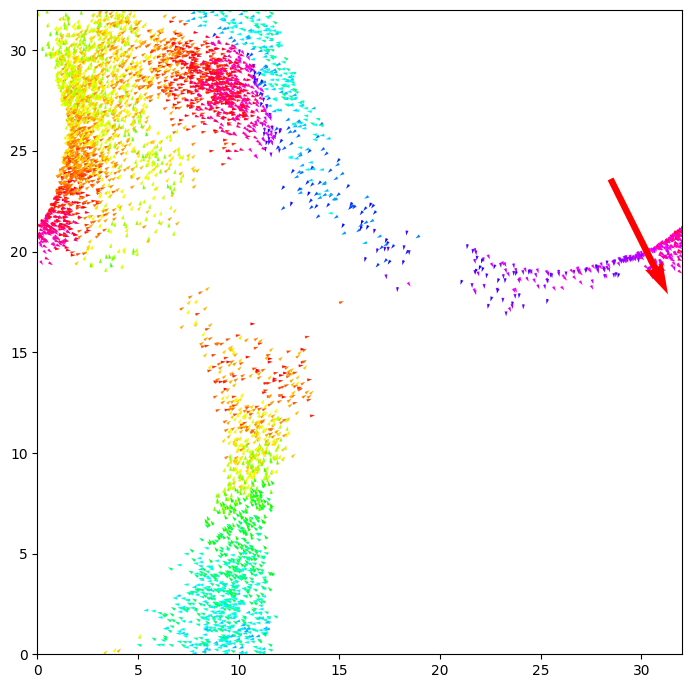

In [24]:
position = generate_positions()
orientation = generate_orientation()
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect('equal')
colors = angle_to_colors(orientation[BIRDS])
quiver = ax.quiver(
    position[BIRDS, 0], position[BIRDS, 1],
    np.cos(orientation[BIRDS]), np.sin(orientation[BIRDS]),
    color=colors
)
prayer_quiver = ax.quiver(
    position[PRAYER, 0], position[PRAYER, 1],
    np.cos(orientation[PRAYER]), np.sin(orientation[PRAYER]),
    color='red', scale=5, width=0.01
)

def update(frame):
    global position, orientation
    position, orientation = step(position, orientation, alpha, v, N, L)
    colors = angle_to_colors(orientation[BIRDS])
    quiver.set_offsets(position[BIRDS])
    quiver.set_UVC(np.cos(orientation[BIRDS]), np.sin(orientation[BIRDS]))
    quiver.set_color(colors)
    prayer_quiver.set_offsets(position[PRAYER])
    prayer_quiver.set_UVC(np.cos(orientation[PRAYER]), np.sin(orientation[PRAYER]))
    return quiver, prayer_quiver

anim = animation.FuncAnimation(fig, update, frames=num_iter, interval=40, blit=True)
plt.tight_layout()
anim.save("birds_prayer.mp4", writer="ffmpeg", fps=20)
plt.show()